In [1]:
%load_ext autoreload
%autoreload 2

import os

import matplotlib.pyplot as plt
import numpy as np
import unyt as u

import dev
import richio

Rstar = 1 * richio.units.lscale
Mstar = 1 * richio.units.mscale
Mbh = 1e6 * richio.units.mscale
r_a = Rstar * (Mbh / Mstar) ** (2 / 3)
r_p = Rstar * (Mbh / Mstar) ** (1 / 3)
r_amin = Rstar * (Mbh / Mstar) ** (2 / 3)
tmin = (
    np.pi / np.sqrt(2) * (Rstar**3 / u.G / Mstar) ** (1 / 2) * (Mbh / Mstar) ** (1 / 2)
)

In [2]:
DATADIR = "/data1/projects/pi-rossiem/TDE_data/SS24_diag/TEMPTDE4"
!ls $DATADIR

snap_626.h5  snap_681.h5  snap_736.h5  snap_791.h5  snap_846.h5  snap_901.h5
snap_627.h5  snap_682.h5  snap_737.h5  snap_792.h5  snap_847.h5  snap_902.h5
snap_628.h5  snap_683.h5  snap_738.h5  snap_793.h5  snap_848.h5  snap_903.h5
snap_629.h5  snap_684.h5  snap_739.h5  snap_794.h5  snap_849.h5  snap_904.h5
snap_630.h5  snap_685.h5  snap_740.h5  snap_795.h5  snap_850.h5  snap_905.h5
snap_631.h5  snap_686.h5  snap_741.h5  snap_796.h5  snap_851.h5  snap_906.h5
snap_632.h5  snap_687.h5  snap_742.h5  snap_797.h5  snap_852.h5  snap_907.h5
snap_633.h5  snap_688.h5  snap_743.h5  snap_798.h5  snap_853.h5  snap_908.h5
snap_634.h5  snap_689.h5  snap_744.h5  snap_799.h5  snap_854.h5  snap_909.h5
snap_635.h5  snap_690.h5  snap_745.h5  snap_800.h5  snap_855.h5  snap_910.h5
snap_636.h5  snap_691.h5  snap_746.h5  snap_801.h5  snap_856.h5  snap_911.h5
snap_637.h5  snap_692.h5  snap_747.h5  snap_802.h5  snap_857.h5  snap_912.h5
snap_638.h5  snap_693.h5  snap_748.h5  snap_803.h5  snap_858.h5  snap_913.h5

722 24.267592053512384 day


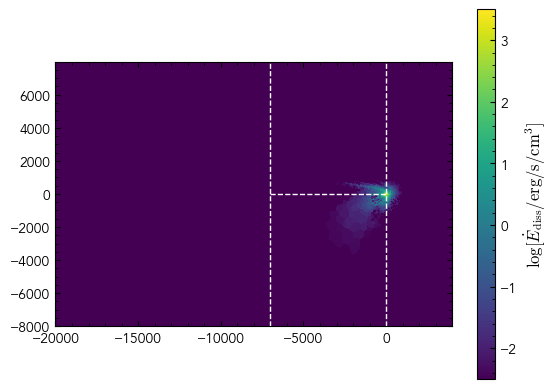

In [5]:
snapnum = 722
SNAPDIR = os.path.join(DATADIR, f"snap_{snapnum}.h5")
snap = richio.load(SNAPDIR)
print(snapnum, snap.time.in_units("day"))

t = snap.time
t_in_tmin = t / tmin
r_a = r_amin * (t_in_tmin) ** (2 / 3)

# x0 = dev.reference_frame_offset(t=t, Mbh=Mbh, Mstar=Mstar, Rstar=Rstar, beta=1)
# X = snap.X + x0[0]
# Y = snap.Y + x0[1]
# for dissipation no need for velocity change
snap.plots.slice(
    "dissipation",
    # X=X,
    # Y=Y,
    # Z=snap.Z,
    res=512,
    box_size=[-20000, -8000, -4000, 4000, 8000, 4000],
    label_latex=r"\dot{E}_\mathrm{diss}",
    unit_latex=r"\mathrm{erg/s/cm^3}",
    cmap="viridis",
)
plt.axvline(0, color="white", linestyle="--", linewidth=1)
plt.axvline(-r_a, color="white", linestyle="--", linewidth=1)
plt.plot([-r_a, 0], [0, 0], color="white", linestyle="--", linewidth=1)
plt.show()


722 24.267592053512384 day


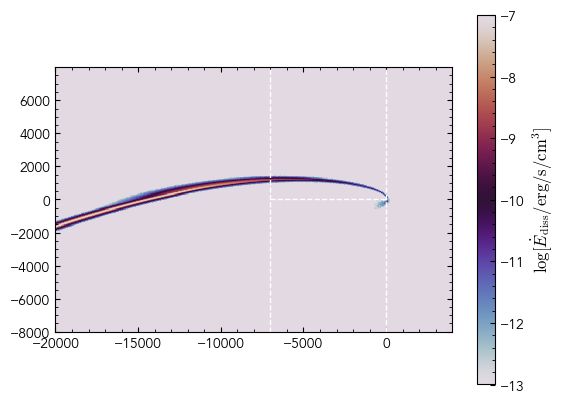

In [ ]:
snapnum = 722
SNAPDIR = os.path.join(DATADIR, f"snap_{snapnum}.h5")
snap = richio.load(SNAPDIR)
print(snapnum, snap.time.in_units("day"))

t = snap.time
t_in_tmin = t / tmin
r_a = r_amin * (t_in_tmin) ** (2 / 3)

snap.plots.slice(
    "density",
    res=512,
    box_size=[-20000, -8000, -4000, 4000, 8000, 4000],
    label_latex=r"\dot{E}_\mathrm{diss}",
    unit_latex=r"\mathrm{erg/s/cm^3}",
)
plt.axvline(0, color="white", linestyle="--", linewidth=1)
plt.axvline(-r_a, color="white", linestyle="--", linewidth=1)
plt.plot([-r_a, 0], [0, 0], color="white", linestyle="--", linewidth=1)
plt.show()


In [ ]:
snapnum = 800
SNAPDIR = os.path.join(DATADIR, f"snap_{snapnum}.h5")
snap = richio.load(SNAPDIR)

r_vec = u.unyt_array([snap.X, snap.Y, snap.Z])
r = np.sum(r_vec**2, axis=0) ** 0.5
# selection = r > 0.6 * 100 * richio.units.lscale
selection = np.ones_like(r, dtype=bool)

diss = snap.dissipation
V = snap.volume

R_diss_vec = [np.sum((diss * V * r_vec[i,:])[selection]) / np.sum((diss * V)[selection]) for i in range(3)]
print(R_diss_vec)

R_diss = np.sum((diss * V * r)[selection]) / np.sum((diss * V)[selection])
print(R_diss)

R_diss_full = R_diss_vec / np.linalg.norm(R_diss_vec)
R_diss_full *= R_diss

[unyt_quantity(-10.82330972, 'code_length'), unyt_quantity(-437.0304473, 'code_length'), unyt_quantity(-5.74745055, 'code_length')]
1012.6561083048174 code_length


800 33.97993764490918 day


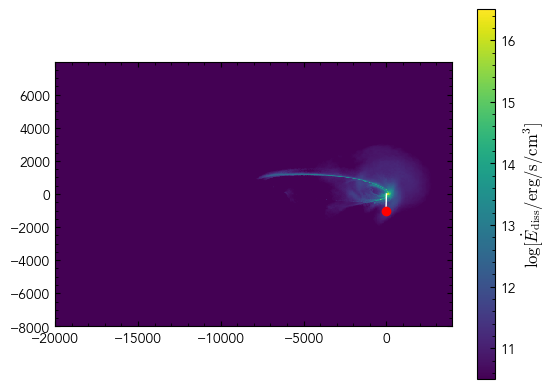

In [ ]:
snapnum = 800
SNAPDIR = os.path.join(DATADIR, f"snap_{snapnum}.h5")
snap = richio.load(SNAPDIR)
print(snapnum, snap.time.in_units("day"))

snap.plots.projection(
    "dissipation",
    res=512,
    # box_size=[-1000, -1000, -1000, 1000, 1000, 1000],
    box_size=[-20000, -8000, -4000, 4000, 8000, 4000],
    label_latex=r"\dot{E}_\mathrm{diss}",
    unit_latex=r"\mathrm{erg/s/cm^3}",
    cmap="viridis",
)
px = [0, R_diss_full[0]]
py = [0, R_diss_full[1]]
plt.plot(px, py, color='white')
plt.scatter(R_diss_full[0], R_diss_full[1], color='red', zorder=10)
plt.show()


In [ ]:
R_diss = u.unyt_array(R_diss)

In [ ]:
np.sqrt(np.sum(R_diss**2))

unyt_quantity(1012.6561083, 'code_length')